In [4]:
from datasets import load_dataset

ds = load_dataset("JacobLinCool/VoiceBank-DEMAND-16k")

In [5]:
import torch

class TestDataset(torch.utils.data.Dataset):
    def __init__(self,ds):
        super().__init__()
        self.ds = ds

    def __getitem__(self, index):
        
        return torch.tensor(self.ds[index]['noisy']['array']).to(torch.float32),  torch.tensor(self.ds[index]['clean']['array']).to(torch.float32), 
    
    def __len__(self):
        return self.ds.__len__()
    

test_set = TestDataset(ds['test'])
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, )
a = next(iter(test_loader))[0]
a.shape

torch.Size([1, 27861])

In [ ]:
import cpuinfo
from time import perf_counter
from loaders import *
from lightning_modules.lightning_module import *
from utils.cfg_loader import load_cfg
import GPUtil
from torchmetrics.audio import( ScaleInvariantSignalDistortionRatio as SISDR, SignalDistortionRatio as SDR,
                                SignalNoiseRatio as SNR, ScaleInvariantSignalNoiseRatio as SISNR,
                                PerceptualEvaluationSpeechQuality as PESQ,
                                ShortTimeObjectiveIntelligibility as STOI)



cfg_path = 'configs/denoise_model_v2_cfg.yaml'
#ckpt_path = '/ckpts/ultra/checkpoints/last.ckpt'
#ckpt_path = '/ckpts/ultra/checkpoints/best-checkpoint-epoch=12-valid_loss=0.80.ckpt'
#ckpt_path = '/ckpts/ultra/checkpoints/best-checkpoint-epoch=00-valid_loss=0.79.ckpt'
#ckpt_path = '/ckpts/ultramax/best-checkpoint-epoch=01-valid_snr=5.00.ckpt'
model_cfg = load_cfg(cfg_path)

metrics = dict( pesq_wb = PESQ(16000, 'wb'),
                pesq_nb = PESQ(16000, 'nb'),
                stoi = STOI(16000),
                snratio = SNR(),
                sdratio = SDR(),
                sisdratio = SISDR(),
                sisnratio = SISNR())
                

#model = GiGaSpectrogramLightningModelUnet.load_from_checkpoint(ckpt_path, **model_cfg)
#model = UltraMaxSpectrogramLightningModelUnet.load_from_checkpoint(ckpt_path, **model_cfg)
#model = SpectrogramLightningModelUnet.load_from_checkpoint(ckpt_path, **model_cfg)



info = cpuinfo.get_cpu_info()
gpus = GPUtil.getGPUs()
print(" "*50)
print("-"*20 + 'DEVICE INFO' + "-"*20)
print(f"Процессор: {info['brand_raw']}")
print(f"Количество ядер: {info['count']}")
for g in gpus:
    print(f"Видеокарта: {g.name}")
    print(f"Память: {g.memoryTotal} MB")
    print(f"Используется памяти: {g.memoryUsed} MB")
    print(f"Загрузка GPU: {g.load * 100}%")
print("-"*20 + '----------' + "-"*20)   

def reset_metrics(metrics):
    """Сбрасывает все метрики перед новым вычислением."""
    for metric in metrics.values():
        metric.reset()

def compute_metrics(cleaned_wf, clean_wf, metric):
        cleaned_wf = cleaned_wf.detach().cpu()
        clean_wf = clean_wf.detach().cpu()
        cleaned_wf_shape = cleaned_wf.shape[-1]
        clean_wf_shape = clean_wf.shape[-1]
        if cleaned_wf.shape[1] != 1:
            cleaned_wf = cleaned_wf.sum(1, keepdims=True)
        if clean_wf.shape[1] != 1:
            clean_wf = clean_wf.sum(1, keepdims=True)
        if clean_wf_shape == min(clean_wf_shape, cleaned_wf_shape):
            cleaned_wf = cleaned_wf[:, :, :clean_wf_shape]
        else:
            clean_wf = clean_wf[:, :, :cleaned_wf_shape]

        
        for k in metric.keys():
            metric[k].update(cleaned_wf, clean_wf) 
        
        
def bench_model(model,metrics, loader, num_iters=100, run='cpu'):

    assert run in {'cpu', 'cuda','mps'}
    model.eval()
    perf_afg = []
    reset_metrics(metrics)

    if num_iters=="max":
        num_iters=len(test_loader)
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            
            
            mixed, clean = batch

            clean = clean.to(run)
            mixed = mixed.to(run)
            model = model.to(run)

            if mixed.ndim == 2 and mixed.shape[0] > 1:
                mixed = mixed.sum(0, keepdim=True)
            
            if mixed.ndim == 3 and mixed.shape[1] > 1:
                mixed = mixed.sum(1, keepdim=True)

            if clean.ndim == 2 and clean.shape[0] > 1:
                clean = clean.sum(0, keepdim=True)
            
            if clean.ndim == 3 and clean.shape[1] > 1:
                clean = clean.sum(1, keepdim=True)

            start = perf_counter()
            out = model.run(mixed)
            delta = perf_counter() - start
            perf_afg.append(delta)

            if out.shape[-1] > clean.shape[-1]:
                out = out[..., :clean.shape[-1]]
        
            if clean.ndim != out.ndim:
                clean = clean[None, ...]

            compute_metrics(out, clean, metrics)
            
            if (i + 1) % (num_iters) == 0:
                break

        metric_values = {k: metrics[k].compute().item() for k in metrics.keys()}

    return perf_afg, metric_values


model


                                                  
--------------------DEVICE INFO--------------------
Процессор: Intel(R) Core(TM) i5-10300H CPU @ 2.50GHz
Количество ядер: 8
Видеокарта: NVIDIA GeForce GTX 1650
Память: 4096.0 MB
Используется памяти: 103.0 MB
Загрузка GPU: 0.0%
--------------------------------------------------


GiGaSpectrogramLightningModelUnet(
  (stft): Spectrogram()
  (model): DenoisingModelUnet(
    (encoder): SpectrumEncoder(
      (encoder_features): Sequential(
        (layer_0): AdaptiveResBlock(
          (block): MobileBlock(
            (conv): Conv2d(1, 8, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
            (depth_wise): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), groups=8)
            (point_wise): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1), padding=(4, 4))
            (bn): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ELU(alpha=1.0)
            (dropout): Dropout2d(p=0.2, inplace=False)
          )
          (scale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (adapt_res): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (layer_1): AdaptiveResBlock(
          (block): MobileBlock(
            (conv): Conv2d(8, 32, kernel_size=(7, 7), strid

# Test Wind

In [15]:
from IPython.display import Audio 
audio, sr = torchaudio.load('examples/test_wind.wav')
audio.shape, sr
audio = torchaudio.functional.resample(audio, sr, 16000)
audio = audio.to('cuda')
with torch.no_grad():
    cleaned = model.run(audio)

display(Audio(audio.detach().cpu().numpy()[0], rate=16000))
display(Audio(cleaned.detach().cpu().numpy()[0], rate=16000))
torchaudio.save('examples/ultra_ckpt2_cleaned_test_wind.wav', cleaned[0].detach().cpu(), sample_rate=16000)

# VoiceBank + DEMAND

In [7]:
perf, metric_values = bench_model(model, metrics, loader=test_loader, num_iters='max',
                                  run='cuda')


"""print('-'*20 + '+CPU+' + '-'*20)
print('Avg CPU Inference [s] : ', torch.tensor(cpu).mean().item())
print('-'*20 + '-----' + '-'*20)"""
print('-'*20 + '+GPU+' + '-'*20)
print('Avg GPU Inference [s] : ', torch.tensor(perf).mean().item())
print('-'*20 + '-----' + '-'*20)
print('-'*19 + 'METRICS' + '-'*19 )
print(f"SNR [dB]: {metric_values['snratio']}"),
print(f"SDR [dB]: {metric_values['sdratio']}")
print(f"SI-SDR [dB]: {metric_values['sisdratio']}")
print(f"SI-SNR [dB]: {metric_values['sisnratio']}")
print(f"STOI: {metric_values['stoi']}")
print(f"PESQ-NB: {metric_values['pesq_nb']}")
print(f"PESQ-WB: {metric_values['pesq_wb']}")

print('-'*19 + '-------' + '-'*19 )
print(" "*50)

--------------------+GPU+--------------------
Avg GPU Inference [s] :  0.12629598379135132
---------------------------------------------
-------------------METRICS-------------------
SNR [dB]: 3.2704365253448486
SDR [dB]: 4.099029541015625
SI-SDR [dB]: 3.8916831016540527
SI-SNR [dB]: 3.8920693397521973
STOI: 0.8971628546714783
PESQ-NB: 2.7138967514038086
PESQ-WB: 1.8724346160888672
---------------------------------------------
                                                  


(array([  8.,  54., 102., 160., 168.,  94.,  72.,  52.,  31.,  23.,  15.,
         11.,   8.,   3.,   7.,   4.,   0.,   1.,   5.,   0.,   0.,   1.,
          1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.84440286, 0.89275816, 0.94111347, 0.98946877, 1.03782407,
        1.08617938, 1.13453468, 1.18288998, 1.23124529, 1.27960059,
        1.32795589, 1.3763112 , 1.4246665 , 1.4730218 , 1.52137711,
        1.56973241, 1.61808772, 1.66644302, 1.71479832, 1.76315363,
        1.81150893, 1.85986423, 1.90821954, 1.

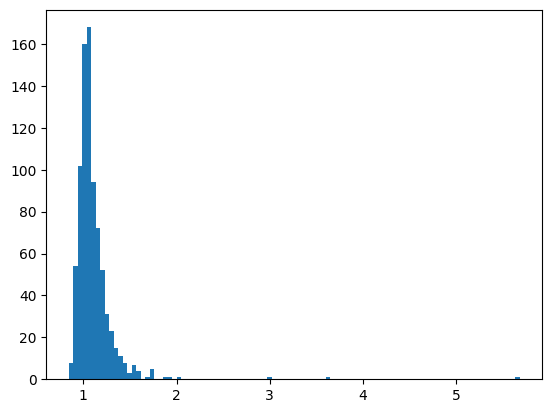

In [10]:
import matplotlib.pyplot as plt
plt.hist(perf, bins=100)

In [21]:
audio = list(iter(test_loader))[-132]
audio[0].shape
mixed = audio[0].to('cuda')
with torch.no_grad():
    cleaned = model.run(mixed)

cleaned.shape

torch.Size([1, 1, 32127])

In [23]:
from IPython.display import Audio 

display(Audio(cleaned.detach().cpu().numpy()[0], rate=16000))
display(Audio(audio[0].detach().cpu().numpy()[0], rate=16000))
display(Audio(audio[1].detach().cpu().numpy()[0], rate=16000))

torchaudio.save('examples/1voicebank_demand_ultra_cleaned.wav', torch.tensor(cleaned[0].detach().cpu()), sample_rate=16000)
#torchaudio.save('examples/voicebank_demand_ultra_noisy.wav', torch.tensor(audio[0].detach().cpu()), sample_rate=16000)
#torchaudio.save('examples/voicebank_demand_ultra_clean.wav', torch.tensor(audio[1]), sample_rate=16000)



/tmp/ipykernel_56931/1083937214.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torchaudio.save('examples/1voicebank_demand_ultra_cleaned.wav', torch.tensor(cleaned[0].detach().cpu()), sample_rate=16000)


# LibreSpeech + Wham

In [7]:
_, _, test_loader = get_loaders(speech_dirs=["dataset/dev-clean", "dataset/test-clean"],
                                                    noise_dir="dataset/wham_noise/wham_noise",
                                                    batch_size=1,
                                                    padding_strategy=None)

#print(next(iter(test_loader))[0].shape)
perf, metric_values = bench_model(model, metrics, loader=test_loader, num_iters='max',
                                  run='cuda')


"""print('-'*20 + '+CPU+' + '-'*20)
print('Avg CPU Inference [s] : ', torch.tensor(cpu).mean().item())
print('-'*20 + '-----' + '-'*20)"""
print('-'*20 + '+GPU+' + '-'*20)
print('Avg GPU Inference [s] : ', torch.tensor(perf).mean().item())
print('-'*20 + '-----' + '-'*20)
print('-'*19 + 'METRICS' + '-'*19 )
print(f"SNR [dB]: {metric_values['snratio']}"),
print(f"SDR [dB]: {metric_values['sdratio']}")
print(f"SI-SDR [dB]: {metric_values['sisdratio']}")
print(f"SI-SNR [dB]: {metric_values['sisnratio']}")
print(f"STOI: {metric_values['stoi']}")
print(f"PESQ-NB: {metric_values['pesq_nb']}")
print(f"PESQ-WB: {metric_values['pesq_wb']}")

print('-'*19 + '-------' + '-'*19 )
print(" "*50)

--------------------+GPU+--------------------
Avg GPU Inference [s] :  0.11684386432170868
---------------------------------------------
-------------------METRICS-------------------
SNR [dB]: 8.2271089553833
SDR [dB]: 7.959918975830078
SI-SDR [dB]: 7.654404163360596
SI-SNR [dB]: 7.65561580657959
STOI: 0.9004573225975037
PESQ-NB: 2.4258623123168945
PESQ-WB: 1.7837904691696167
---------------------------------------------
                                                  


In [ ]:
from IPython.display import Audio 
_, _, test_loader = get_loaders(speech_dirs=["dataset/dev-clean", "dataset/test-clean"],
                                                    noise_dir="dataset/wham_noise/wham_noise",
                                                    batch_size=1,
                                                    padding_strategy=None)


In [16]:
audio = list(iter(test_loader))[113]

mixed = audio[0]
with torch.no_grad():
    cleaned = model.run(mixed.to('cuda'))



display(Audio(cleaned.detach().cpu().numpy()[0], rate=16000))
display(Audio(audio[0].detach().cpu().numpy()[0], rate=16000))
display(Audio(audio[1].detach().cpu().numpy()[0], rate=16000))

In [17]:
torchaudio.save('examples/1librispeech_wham_ultra_cleaned.wav', torch.tensor(cleaned[0]), sample_rate=16000)
#torchaudio.save('examples/1librispeech_wham_ultra_noisy.wav', torch.tensor(audio[0].detach().cpu().sum(1)), sample_rate=16000)
#torchaudio.save('examples/1librispeech_wham_ultra_clean.wav', torch.tensor(audio[1].detach().cpu().sum(1)), sample_rate=16000)

/tmp/ipykernel_56931/3552978104.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torchaudio.save('examples/1librispeech_wham_ultra_cleaned.wav', torch.tensor(cleaned[0]), sample_rate=16000)


In [44]:
audio[0].shape

torch.Size([1, 2, 128000])